In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. Load dataset

In [2]:
df = pd.read_csv('Greenhouse Plant Growth Metrics.csv')
df

,Random,ACHP,PHR,AWWGV,ALAP,ANPL,ARD,ADWR,PDMVG,ARL,AWWR,ADWV,PDMRG,Class
0,R1,34.533468,54.566983,1.147449,1284.229549,4.999713,16.274918,1.706810,18.399982,19.739037,2.949240,0.209251,57.633906,SA
1,R1,34.489028,54.567692,1.149530,1284.247744,5.024259,16.269452,1.700930,18.398289,19.758836,2.943137,0.216154,57.633697,SA
2,R2,33.100405,67.067344,1.104647,1009.208996,5.007652,15.980760,1.185391,19.398789,20.840822,2.861635,0.200113,41.289875,SA
3,R1,34.498319,54.559049,1.137759,1284.227623,4.991501,16.276710,1.716396,18.413613,19.736098,2.946784,0.223092,57.645661,SA
4,R3,36.297008,45.588894,1.363205,981.470310,4.003682,16.979894,0.777428,31.423772,17.331894,2.766242,0.424172,27.898619,SA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,R3,46.400873,50.830830,0.883813,744.310093,4.012024,17.796293,1.085930,12.812881,18.457811,3.264946,0.108366,33.343799,TC
29996,R3,46.395047,50.838058,0.900390,744.307234,4.011764,17.809462,1.108226,12.822240,18.457313,3.259574,0.129387,33.338906,TC
29997,R2,32.707725,37.065408,0.909055,857.849380,2.992712,18.200984,0.903880,8.050019,19.070005,3.495121,0.056698,26.041147,TC
29998,R1,38.624079,37.876323,1.077557,948.663424,4.002284,15.733098,1.238818,11.953827,19.164418,3.141850,0.116892,39.125346,TC


Conclusion: exclude random and class from clustering

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Random  30000 non-null  str    
 1   ACHP    30000 non-null  float64
 2   PHR     30000 non-null  float64
 3   AWWGV   30000 non-null  float64
 4   ALAP    30000 non-null  float64
 5   ANPL    30000 non-null  float64
 6   ARD     30000 non-null  float64
 7   ADWR    30000 non-null  float64
 8   PDMVG   30000 non-null  float64
 9   ARL     30000 non-null  float64
 10  AWWR    30000 non-null  float64
 11  ADWV    30000 non-null  float64
 12  PDMRG   30000 non-null  float64
 13  Class   30000 non-null  str    
dtypes: float64(12), str(2)
memory usage: 3.2 MB
None


In [4]:
print(df.isnull().sum())

Random    0
ACHP      0
PHR       0
AWWGV     0
ALAP      0
ANPL      0
ARD       0
ADWR      0
PDMVG     0
ARL       0
AWWR      0
ADWV      0
PDMRG     0
Class     0
dtype: int64


No labels on plant health. Proceed to perform clustering and analyse them.

In [5]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

Approach: Excluding class column completely.

In [6]:
df_cluster = df.iloc[:, 1:-1]
df_cluster

,ACHP,PHR,AWWGV,ALAP,ANPL,ARD,ADWR,PDMVG,ARL,AWWR,ADWV,PDMRG
0,34.533468,54.566983,1.147449,1284.229549,4.999713,16.274918,1.706810,18.399982,19.739037,2.949240,0.209251,57.633906
1,34.489028,54.567692,1.149530,1284.247744,5.024259,16.269452,1.700930,18.398289,19.758836,2.943137,0.216154,57.633697
2,33.100405,67.067344,1.104647,1009.208996,5.007652,15.980760,1.185391,19.398789,20.840822,2.861635,0.200113,41.289875
3,34.498319,54.559049,1.137759,1284.227623,4.991501,16.276710,1.716396,18.413613,19.736098,2.946784,0.223092,57.645661
4,36.297008,45.588894,1.363205,981.470310,4.003682,16.979894,0.777428,31.423772,17.331894,2.766242,0.424172,27.898619
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,46.400873,50.830830,0.883813,744.310093,4.012024,17.796293,1.085930,12.812881,18.457811,3.264946,0.108366,33.343799
29996,46.395047,50.838058,0.900390,744.307234,4.011764,17.809462,1.108226,12.822240,18.457313,3.259574,0.129387,33.338906
29997,32.707725,37.065408,0.909055,857.849380,2.992712,18.200984,0.903880,8.050019,19.070005,3.495121,0.056698,26.041147
29998,38.624079,37.876323,1.077557,948.663424,4.002284,15.733098,1.238818,11.953827,19.164418,3.141850,0.116892,39.125346


In [7]:
X_cluster = df_cluster.copy()
X_cluster

,ACHP,PHR,AWWGV,ALAP,ANPL,ARD,ADWR,PDMVG,ARL,AWWR,ADWV,PDMRG
0,34.533468,54.566983,1.147449,1284.229549,4.999713,16.274918,1.706810,18.399982,19.739037,2.949240,0.209251,57.633906
1,34.489028,54.567692,1.149530,1284.247744,5.024259,16.269452,1.700930,18.398289,19.758836,2.943137,0.216154,57.633697
2,33.100405,67.067344,1.104647,1009.208996,5.007652,15.980760,1.185391,19.398789,20.840822,2.861635,0.200113,41.289875
3,34.498319,54.559049,1.137759,1284.227623,4.991501,16.276710,1.716396,18.413613,19.736098,2.946784,0.223092,57.645661
4,36.297008,45.588894,1.363205,981.470310,4.003682,16.979894,0.777428,31.423772,17.331894,2.766242,0.424172,27.898619
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,46.400873,50.830830,0.883813,744.310093,4.012024,17.796293,1.085930,12.812881,18.457811,3.264946,0.108366,33.343799
29996,46.395047,50.838058,0.900390,744.307234,4.011764,17.809462,1.108226,12.822240,18.457313,3.259574,0.129387,33.338906
29997,32.707725,37.065408,0.909055,857.849380,2.992712,18.200984,0.903880,8.050019,19.070005,3.495121,0.056698,26.041147
29998,38.624079,37.876323,1.077557,948.663424,4.002284,15.733098,1.238818,11.953827,19.164418,3.141850,0.116892,39.125346


In [8]:
# Apply scaling to all columns
preprocessor_cluster = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X_cluster.columns)
    ])

X_scaled_clustered = preprocessor_cluster.fit_transform(X_cluster)

In [9]:
if np.isnan(X_scaled_clustered).any() or np.isinf(X_scaled_clustered).any():
    print("WARNING: NaNs or Infs found in scaled data. This can cause issues with KMeans.")
    #Add imputation if NaNs found
    # Apply nan_to_num to the dense array
    X_scaled_clustered = np.nan_to_num(X_scaled_clustered, nan=0.0, posinf=1e5, neginf=-1e5)
    print("NaNs/Infs replaced with 0 or large values for robustness.")
else:
    print("No NaNs or INFs")

No NaNs or INFs


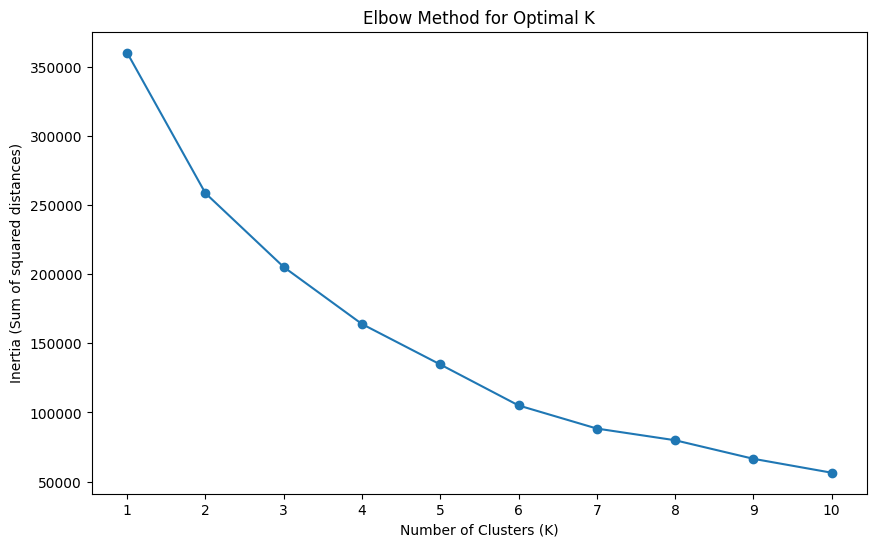

In [ ]:
# Elbow method to find optimal K for clustering
inertias = []
max_k = 10 # Max 10 clusters
for k in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init for robust centroid initialization
    kmeans.fit(X_scaled_clustered) # Use X_scaled_clustered here
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.xticks(range(1, max_k + 1))
plt.show()

In [11]:
optimal_k = 3

# Apply K-Means Clustering
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
# Fit and predict
df_cluster['Cluster'] = kmeans_final.fit_predict(X_scaled_clustered)

print(f"\nClustering performed with K = {optimal_k}.")
print(f"Cluster distribution:\n{df_cluster['Cluster'].value_counts()}")


Clustering performed with K = 3.
Cluster distribution:
Cluster
1    15049
0    11677
2     3274
Name: count, dtype: int64


Inspecting clusters

In [12]:
cluster_means_original_scale = df_cluster.groupby('Cluster')[df_cluster.columns].mean()
print(cluster_means_original_scale)

              ACHP        PHR     AWWGV         ALAP      ANPL        ARD  \
Cluster                                                                     
0        36.431756  51.249491  1.023897  1010.177017  4.288425  17.492708   
1        39.750320  62.277879  1.363512  1010.411718  3.558039  14.215090   
2        36.102955  71.762317  1.509523  1498.983510  4.496886  21.499244   

             ADWR      PDMVG        ARL      AWWR      ADWV      PDMRG  \
Cluster                                                                  
0        1.250068  17.448159  19.149671  3.355188  0.179104  38.234417   
1        0.635809  26.790030  16.187290  1.929523  0.369811  33.260808   
2        1.791110  22.398072  22.882889  5.801586  0.337854  30.745373   

         Cluster  
Cluster           
0            0.0  
1            1.0  
2            2.0  


In [13]:
cluster_0 = df_cluster[df_cluster['Cluster'] == 0]
cluster_1 = df_cluster[df_cluster['Cluster'] == 1]
cluster_2 = df_cluster[df_cluster['Cluster'] == 2]

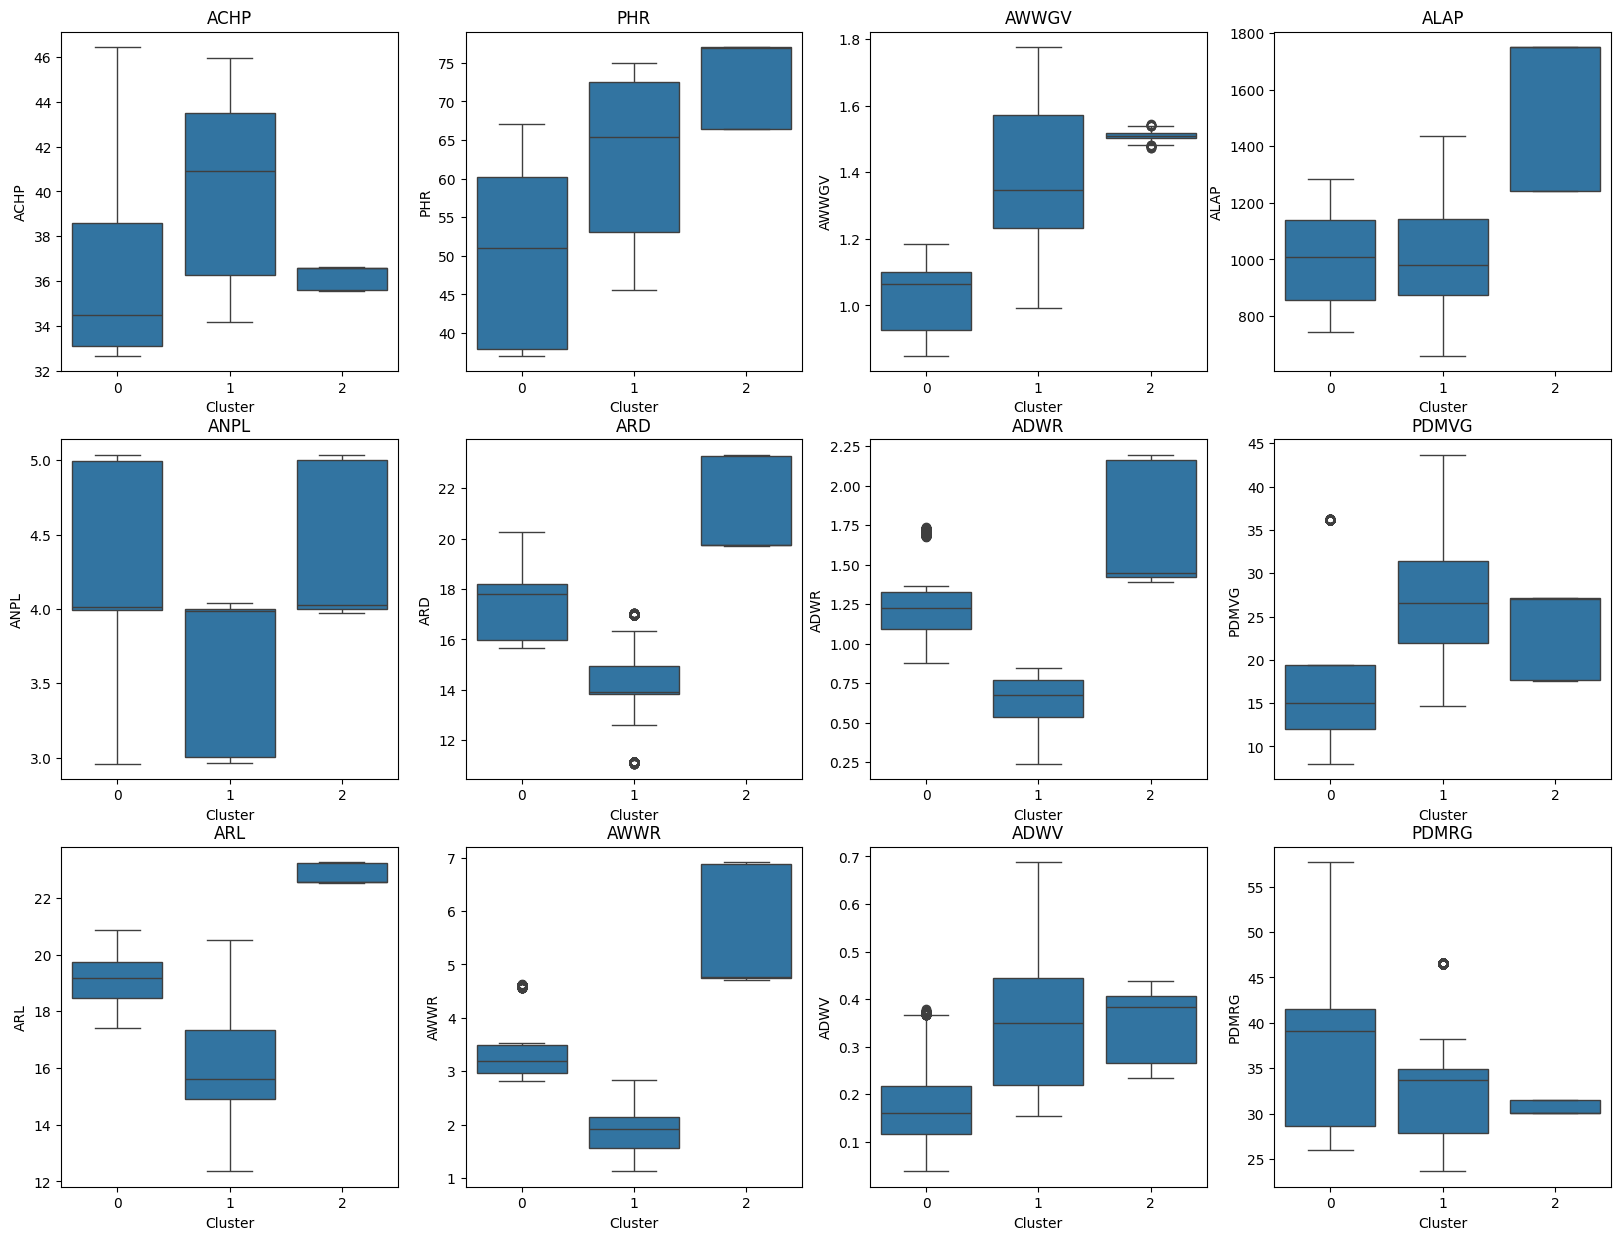

In [22]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(20,15))
ax = ax.flatten()
for i, feature in enumerate(df_cluster.columns[:-1]):
    sns.boxplot(data = df_cluster, x ='Cluster', y = feature, ax = ax[i])
    ax[i].set_title(feature)

Based on the overlaps of boxplots chosen features: AWWGV, ARD, ADWR, ARL, AWWR.

- AWWGV - Average wet weight of vegetative growth
- ARD - Average root diameter
- ADWR - Average dry weight of roots
- ARL - Average root length
- AWWR - Average wet weight of roots


The clusters represent different plant growth patterns based on root and vegetative features:

- **Cluster 2 (High Growth / Healthy Plants)**  
  - High root length, diameter, and biomass  
  - High vegetative growth  
  - → Represents well-developed plants with strong overall growth

- **Cluster 1 (Weak Root System)**  
  - Low root length, diameter, and biomass  
  - Moderate vegetative growth  
  - → Plants with poor root systems, likely limiting nutrient uptake

- **Cluster 0 (Moderate Roots, Low Shoot Growth)**  
  - Moderate root development  
  - Low vegetative growth  
  - → Plants with decent roots but weaker above-ground growth

**Overall Insight:**  
- Cluster 2 = Best-performing plants  
- Cluster 1 = Root-deficient plants  
- Cluster 0 = Moderate plants with inefficient shoot growth